In [4]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [5]:
client = Client()
client

/home/562/cd3007/miniconda3/envs/mhw_env/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33815 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33815/status,
Dashboard: /proxy/33815/status,Workers: 4
Total threads: 12,Total memory: 46.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44951,Workers: 0
Dashboard: /proxy/33815/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45315,Total threads: 3
Dashboard: /proxy/42137/status,Memory: 11.50 GiB
Nanny: tcp://127.0.0.1:44815,


In [18]:
print('Starting ACCESS-OM2 and SOTS SST analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri

#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2 
#----------------------------------------------------------------------------------------------

var    =  'sst'
var_01 = 'surface_pot_temp'

experiments = ['1deg_jra55_iaf_omip2_cycle6', '025deg_jra55_iaf_omip2_cycle6', ['01deg_jra55v140_iaf_cycle4', '01deg_jra55v140_iaf_cycle4_jra55v150_extension']]

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

var_SOTS   =  'temp_mn'

#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([141,146])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]


Starting ACCESS-OM2 and SOTS SST analysis.


In [19]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var_01,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")
    



Processing ACCESS sst data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [20]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    if exp == "01deg_jra55v140_iaf_cycle4":
        var = var_01
        
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    monthly_climatology = heat_flux.groupby('time.month').mean(dim='time')

    exp_heat_flux[exp] = {
        "monthly_mean": monthly_climatology}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()


Start collecting sst 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sst data for ACCESS.
Execution time: 0.08 minutes
Start collecting sst 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sst data for ACCESS.
Execution time: 0.04 minutes
Start collecting surface_pot_temp 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting surface_pot_temp data for ACCESS.
Execution time: 0.51 minutes


In [30]:

#----------------------------------------------------------------------------------------------
# Read and collect data for SOTS
#----------------------------------------------------------------------------------------------

print(f'Processing SOTS {var} data...')
sys.stdout.flush()


SOTS_dir  = '/g/data/jk72/mxr581/SOTS-project-data/sots'
SOTS_pattern = os.path.join(SOTS_dir, "sots.monthly.means.nc")

SOTS_paths = glob.glob(SOTS_pattern)


start = time.time()

ds = xr.open_mfdataset(SOTS_paths)

SOTS_flux = ds[var_SOTS].isel(depth_T=0)

# Get climatology
SOTS_monthly_climatology = SOTS_flux.groupby('time.month').mean(dim='time')

print(SOTS_monthly_climatology.values)

ds.close()

end = time.time()  

print(f'Finished collecting {var} data.')
sys.stdout.flush()

print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing SOTS surface_pot_temp data...
[12.04038611 12.24571871 11.91055967 11.7927468  11.16407786 10.30391271
 10.09750882  9.46323648  9.43811797 10.06232534 10.09218573 10.7966061 ]
Finished collecting surface_pot_temp data.
Execution time: 0.00 minutes


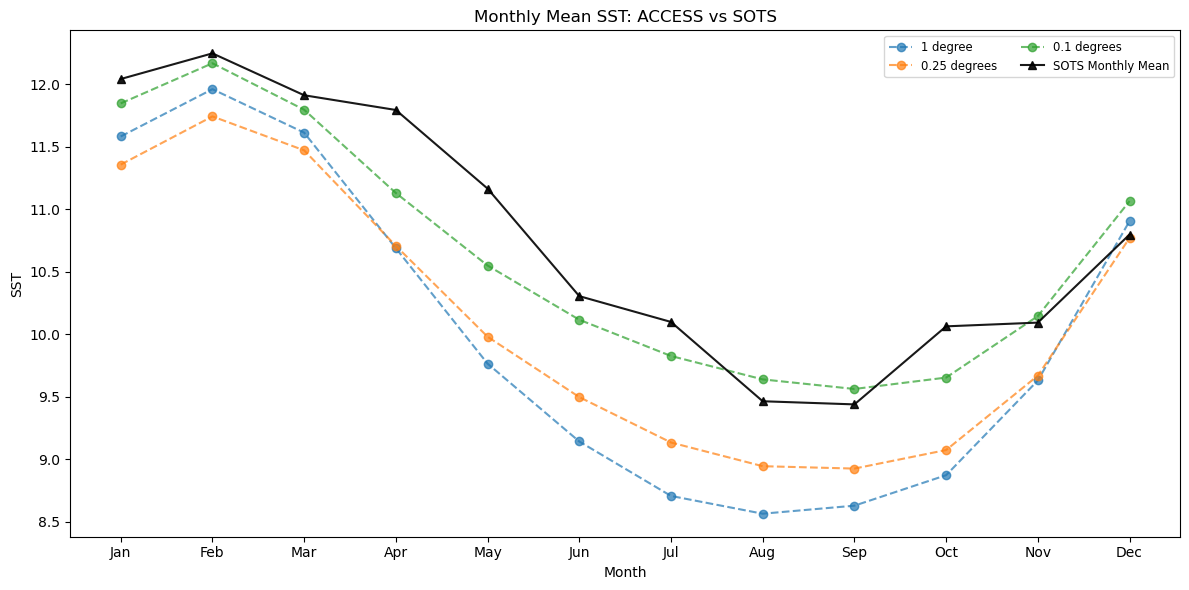

In [32]:
#----------------------------------------------------------------------------------------------
# PLOT
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12,6))

exp_titles = {
    '1deg_jra55_iaf_omip2_cycle6': '1 degree',
    '025deg_jra55_iaf_omip2_cycle6': '0.25 degrees',
    '01deg_jra55v140_iaf_cycle4': '0.1 degrees'
}

for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict['monthly_mean'] - 273.15
    label = exp_titles.get(exp_name, exp_name)
    
    ax.plot(monthly_mean['month'], monthly_mean.values,
            marker='o', linestyle='--', alpha=0.7, label=label)

ax.plot(SOTS_monthly_climatology['month'], SOTS_monthly_climatology.values,
        color='black', marker='^', linestyle='-', alpha=0.9, label='SOTS Monthly Mean')

ax.set_xlabel('Month')
ax.set_ylabel('SST')
ax.set_title('Monthly Mean SST: ACCESS vs SOTS')
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()

